# Suspension GRU — Evaluation

Inference-only notebook. Loads the saved z-score statistics and the trained weights;
nothing about the training pipeline (dataset windowing, optimiser, schedules) is
re-created here. Architecture dimensions are read straight out of the checkpoint.

In [24]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH   = '../data/suspension_dataset.mat'
WEIGHTS     = '../models/gru_bs128_s5_seq1000_100k.pt'
ZSCORE_PATH = '../models/zscore_stats.pkl'      # rename here if your file is zscore_state.pkl

# ── The only things not recoverable from the checkpoint ──────────────────────
SEQ_LEN    = 1000       # road-history window [samples]
BATCH_SIZE = 128        # inference batch size only
Ts         = 0.001      # sampling interval [s]
N          = 100_000    # period length in the .mat file

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

S = joblib.load(ZSCORE_PATH)          # road/body/tyre mean + std
print(f'Device: {device}')
print('Z-score stats: ' + ', '.join(f'{k}={v:+.6g}' for k, v in S.items()))

Device: cuda
Z-score stats: road_mean=+2.22045e-21, road_std=+0.00181347, body_mean=-0.000452808, body_std=+0.00181653, tyre_mean=-0.00010357, tyre_std=+0.00177374


In [25]:
class SuspensionGRU(nn.Module):
    """2 stacked GRU layers -> 3-layer MLP decoder -> (body, tyre)."""

    def __init__(self, input_size, output_size, hidden_size, fc_width):
        super().__init__()
        self.gru1 = nn.GRU(input_size, hidden_size, batch_first=True)
        self.gru2 = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, fc_width)
        self.fc2 = nn.Linear(fc_width, fc_width)
        self.fc3 = nn.Linear(fc_width, fc_width)
        self.fc4 = nn.Linear(fc_width, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x, _ = self.gru1(x)
        x = self.relu(x)
        x, _ = self.gru2(x)
        x = self.relu(x)
        x = x[:, -1, :]                 # many-to-one: last timestep
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        return self.fc4(x)


# ── Build the model from the checkpoint's own shapes ─────────────────────────
sd = torch.load(WEIGHTS, map_location=device)
HIDDEN_DIM = sd['gru1.weight_ih_l0'].shape[0] // 3
FC_WIDTH   = sd['fc1.weight'].shape[0]

model = SuspensionGRU(
    input_size  = sd['gru1.weight_ih_l0'].shape[1],
    output_size = sd['fc4.weight'].shape[0],
    hidden_size = HIDDEN_DIM,
    fc_width    = FC_WIDTH,
).to(device)
model.load_state_dict(sd)
model.eval()

N_PARAMS = sum(p.numel() for p in model.parameters())
print(f'Loaded {WEIGHTS}: hidden={HIDDEN_DIM}, fc_width={FC_WIDTH}, params={N_PARAMS:,}')

Loaded ../models/gru_bs128_s5_seq1000_100k.pt: hidden=128, fc_width=200, params=255,978


In [26]:
raw = sio.loadmat(DATA_PATH)


def predict(road_raw):
    """Road profile [m] -> (body, tyre) predictions [m].

    Output is aligned with road_raw[SEQ_LEN-1:] (one prediction per full window).
    """
    road_sc = (np.asarray(road_raw, dtype=np.float64) - S['road_mean']) / S['road_std']
    windows = np.lib.stride_tricks.sliding_window_view(road_sc, SEQ_LEN)

    out = []
    with torch.inference_mode():
        for i in range(0, len(windows), BATCH_SIZE):
            xb = torch.as_tensor(np.ascontiguousarray(windows[i:i + BATCH_SIZE]),
                                 dtype=torch.float32, device=device).unsqueeze(-1)
            out.append(model(xb).cpu().numpy())
    p = np.concatenate(out, axis=0)

    return (p[:, 0] * S['body_std'] + S['body_mean'],
            p[:, 1] * S['tyre_std'] + S['tyre_mean'])


def align(sig):
    """Trim a ground-truth signal so it lines up with predict() output."""
    return np.asarray(sig)[SEQ_LEN - 1:]


def load_class(cls, period=1):
    """Road (period 1) + unsuppressed body/tyre response for the given period."""
    sl = slice(period * N, (period + 1) * N)
    return (raw[f'hx{cls}'].flatten()[:N],
            raw[f'bodyxsuppressed{cls}'].flatten()[sl],
            raw[f'tirexsuppressed{cls}'].flatten()[sl])


def metrics(pred, true):
    rmse = float(np.sqrt(np.mean((pred - true) ** 2)))
    return {
        'rmse':        rmse * 1000,                                  # mm
        'mae':         float(np.mean(np.abs(pred - true))) * 1000,   # mm
        'nrmse_range': rmse / (true.max() - true.min()) * 100,       # %
        'nrmse_std':   rmse / true.std() * 100,                      # %
        'corr':        float(np.corrcoef(pred, true)[0, 1]),
    }

## Single-class evaluation

In [27]:
ROAD_CLASS = 'E'      # 'A', 'B', 'C', 'D', 'E'

road_raw, body_raw, tyre_raw = load_class(ROAD_CLASS)
preds_body, preds_tyre = predict(road_raw)
targets_body, targets_tyre = align(body_raw), align(tyre_raw)

n = len(preds_body)
title = f'Class {ROAD_CLASS} — Unsuppressed — Period 2'
print(f'{title}\nSamples: {n:,}\n')
for label, pred, true in [('Body', preds_body, targets_body),
                          ('Tyre', preds_tyre, targets_tyre)]:
    m = metrics(pred, true)
    print(f'  {label:6s}  RMSE: {m["rmse"]:.4f} mm   MAE: {m["mae"]:.4f} mm')

Class E — Unsuppressed — Period 2
Samples: 99,001

  Body    RMSE: 0.0709 mm   MAE: 0.0555 mm
  Tyre    RMSE: 0.1002 mm   MAE: 0.0786 mm


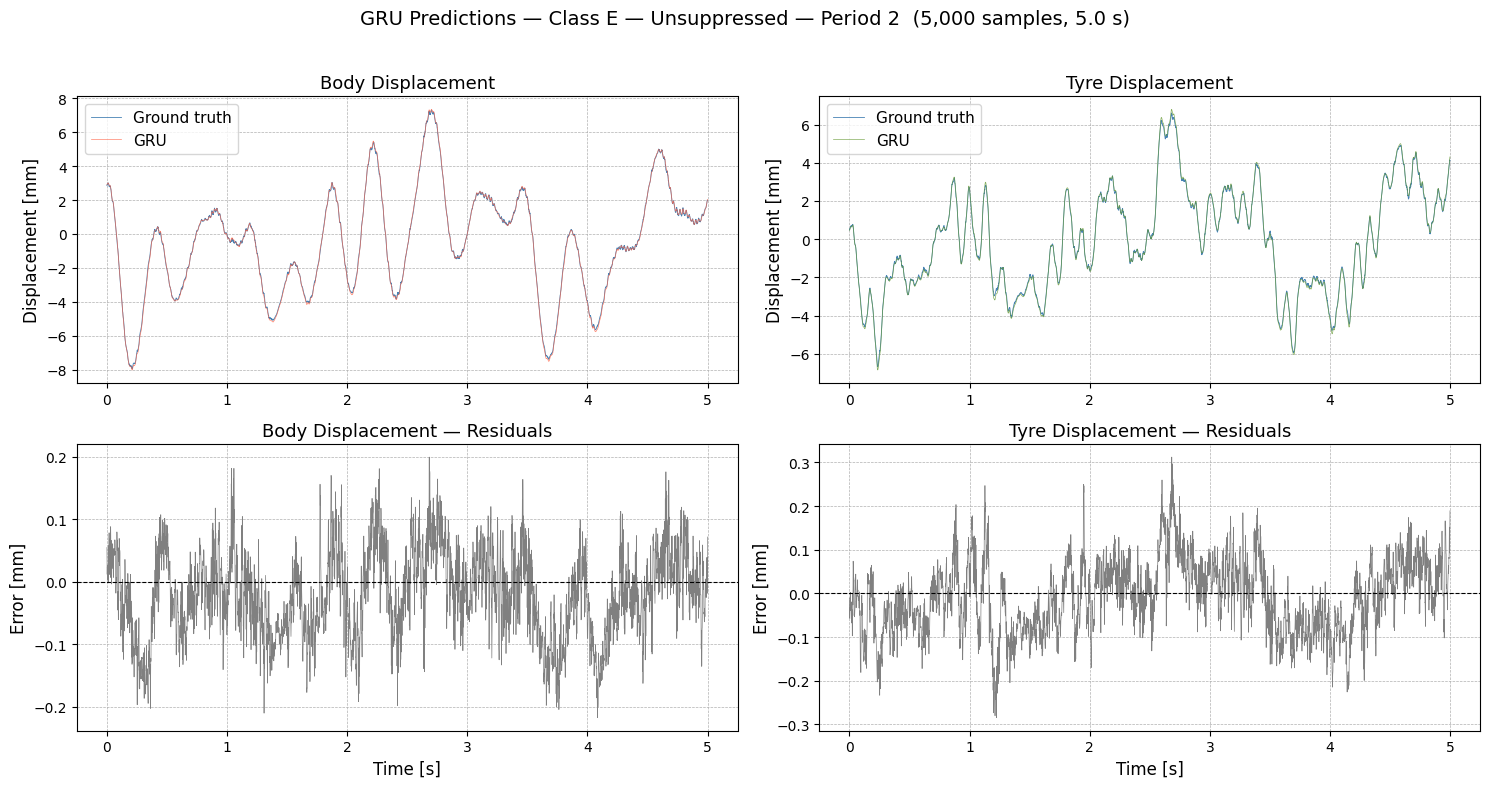

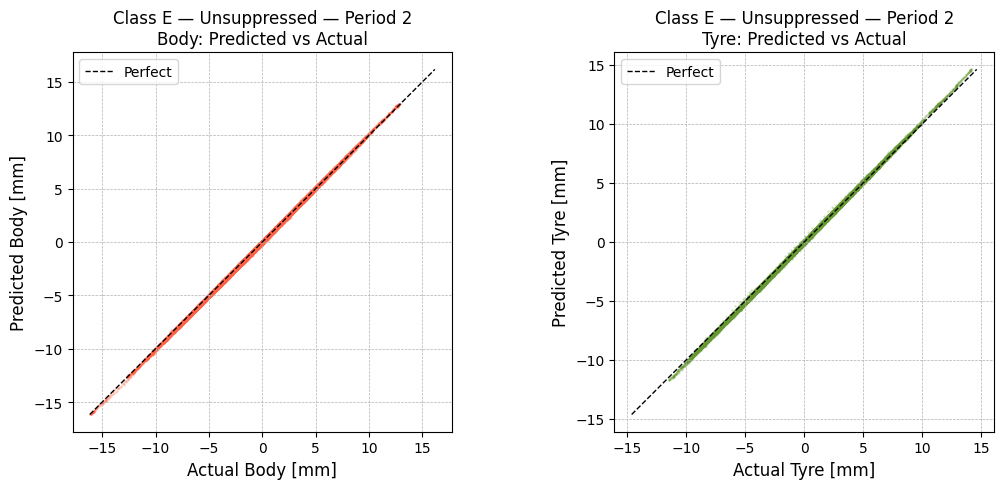

In [20]:
PLOT_SAMPLES = 5000     # None for all

p = min(PLOT_SAMPLES or n, n)
t_plot = np.arange(p) * Ts

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for col_i, (truth, pred, label, col) in enumerate([
    (targets_body, preds_body, 'Body Displacement', 'tomato'),
    (targets_tyre, preds_tyre, 'Tyre Displacement', '#669933'),
]):
    ax_top, ax_bot = axes[0, col_i], axes[1, col_i]
    ax_top.plot(t_plot, truth[:p] * 1000, lw=0.6, color='steelblue', label='Ground truth')
    ax_top.plot(t_plot, pred[:p] * 1000, lw=0.5, color=col, alpha=0.8, label='GRU')
    ax_top.set_title(label, fontsize=13)
    ax_top.set_ylabel('Displacement [mm]', fontsize=12)
    ax_top.legend(fontsize=11)
    ax_top.grid(True, linestyle='--', linewidth=0.5)

    ax_bot.plot(t_plot, (pred[:p] - truth[:p]) * 1000, lw=0.5, color='grey')
    ax_bot.axhline(0, color='k', lw=0.8, ls='--')
    ax_bot.set_title(f'{label} — Residuals', fontsize=13)
    ax_bot.set_ylabel('Error [mm]', fontsize=12)
    ax_bot.set_xlabel('Time [s]', fontsize=12)
    ax_bot.grid(True, linestyle='--', linewidth=0.5)

plt.suptitle(f'GRU Predictions — {title}  ({p:,} samples, {p * Ts:.1f} s)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ── Scatter uses ALL predictions ─────────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
for ax, pred, truth, label, col in [
    (axs[0], preds_body, targets_body, 'Body', 'tomato'),
    (axs[1], preds_tyre, targets_tyre, 'Tyre', '#669933'),
]:
    ax.scatter(truth * 1000, pred * 1000, s=0.3, alpha=0.3, color=col)
    lim = max(np.abs(truth).max(), np.abs(pred).max()) * 1000
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1, label='Perfect')
    ax.set_xlabel(f'Actual {label} [mm]', fontsize=12)
    ax.set_ylabel(f'Predicted {label} [mm]', fontsize=12)
    ax.set_title(f'{title}\n{label}: Predicted vs Actual', fontsize=12)
    ax.set_aspect('equal')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## Per-class metrics

In [21]:
CLASSES = ['A', 'B', 'C', 'D', 'E']
class_results = {}

for cls in CLASSES:
    road, body, tyre = load_class(cls)
    pb, pt = predict(road)
    class_results[cls] = {'body': metrics(pb, align(body)),
                          'tyre': metrics(pt, align(tyre))}

hdr = (f'{"Class":<8} {"RMSE [mm]":<12} {"MAE [mm]":<12} '
       f'{"NRMSE/range":<14} {"NRMSE/std":<14} {"Correlation":<12}')
for key, name in [('body', 'BODY DISPLACEMENT'), ('tyre', 'TYRE DISPLACEMENT')]:
    print(f'\n{name}\n' + hdr + '\n' + '-' * 80)
    for cls in CLASSES:
        r = class_results[cls][key]
        print(f'{cls:<8} {r["rmse"]:<12.4f} {r["mae"]:<12.4f} '
              f'{r["nrmse_range"]:<12.2f}% {r["nrmse_std"]:<12.2f}% {r["corr"]:<12.4f}')


BODY DISPLACEMENT
Class    RMSE [mm]    MAE [mm]     NRMSE/range    NRMSE/std      Correlation 
--------------------------------------------------------------------------------
A        0.0204       0.0173       1.81        % 13.28       % 0.9970      
B        0.0234       0.0194       0.88        % 6.14        % 0.9993      
C        0.0293       0.0230       0.53        % 3.91        % 0.9996      
D        0.0482       0.0380       0.36        % 2.84        % 0.9998      
E        0.0709       0.0555       0.24        % 1.99        % 0.9999      

TYRE DISPLACEMENT
Class    RMSE [mm]    MAE [mm]     NRMSE/range    NRMSE/std      Correlation 
--------------------------------------------------------------------------------
A        0.0142       0.0112       0.91        % 6.62        % 0.9983      
B        0.0207       0.0162       0.60        % 4.36        % 0.9995      
C        0.0360       0.0282       0.56        % 4.16        % 0.9996      
D        0.0623       0.0494       0

## Frequency response (sine sweep)

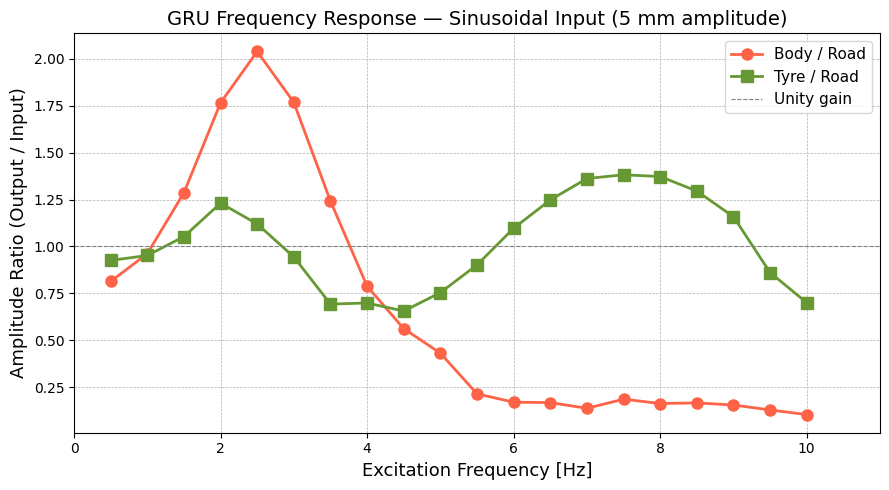

In [22]:
test_freqs = np.linspace(0.5, 10.0, 20)
amplitude  = 0.005                      # 5 mm sine input — within training range
t_test     = np.arange(10_000) * Ts
steady     = int(5.0 / Ts)              # measure amplitude on the last 5 s only

body_gains, tyre_gains = [], []
for freq in test_freqs:
    pb, pt = predict(amplitude * np.sin(2 * np.pi * freq * t_test))
    body_gains.append((pb[steady:].max() - pb[steady:].min()) / 2 / amplitude)
    tyre_gains.append((pt[steady:].max() - pt[steady:].min()) / 2 / amplitude)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(test_freqs, body_gains, 'o-', color='tomato', lw=2, markersize=8, label='Body / Road')
ax.plot(test_freqs, tyre_gains, 's-', color='#669933', lw=2, markersize=8, label='Tyre / Road')
ax.axhline(1.0, color='grey', ls='--', lw=0.8, label='Unity gain')
ax.set_xlabel('Excitation Frequency [Hz]', fontsize=13)
ax.set_ylabel('Amplitude Ratio (Output / Input)', fontsize=13)
ax.set_title('GRU Frequency Response — Sinusoidal Input (5 mm amplitude)', fontsize=14)
ax.set_xlim([0, 11])
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## Speed bump / pothole response

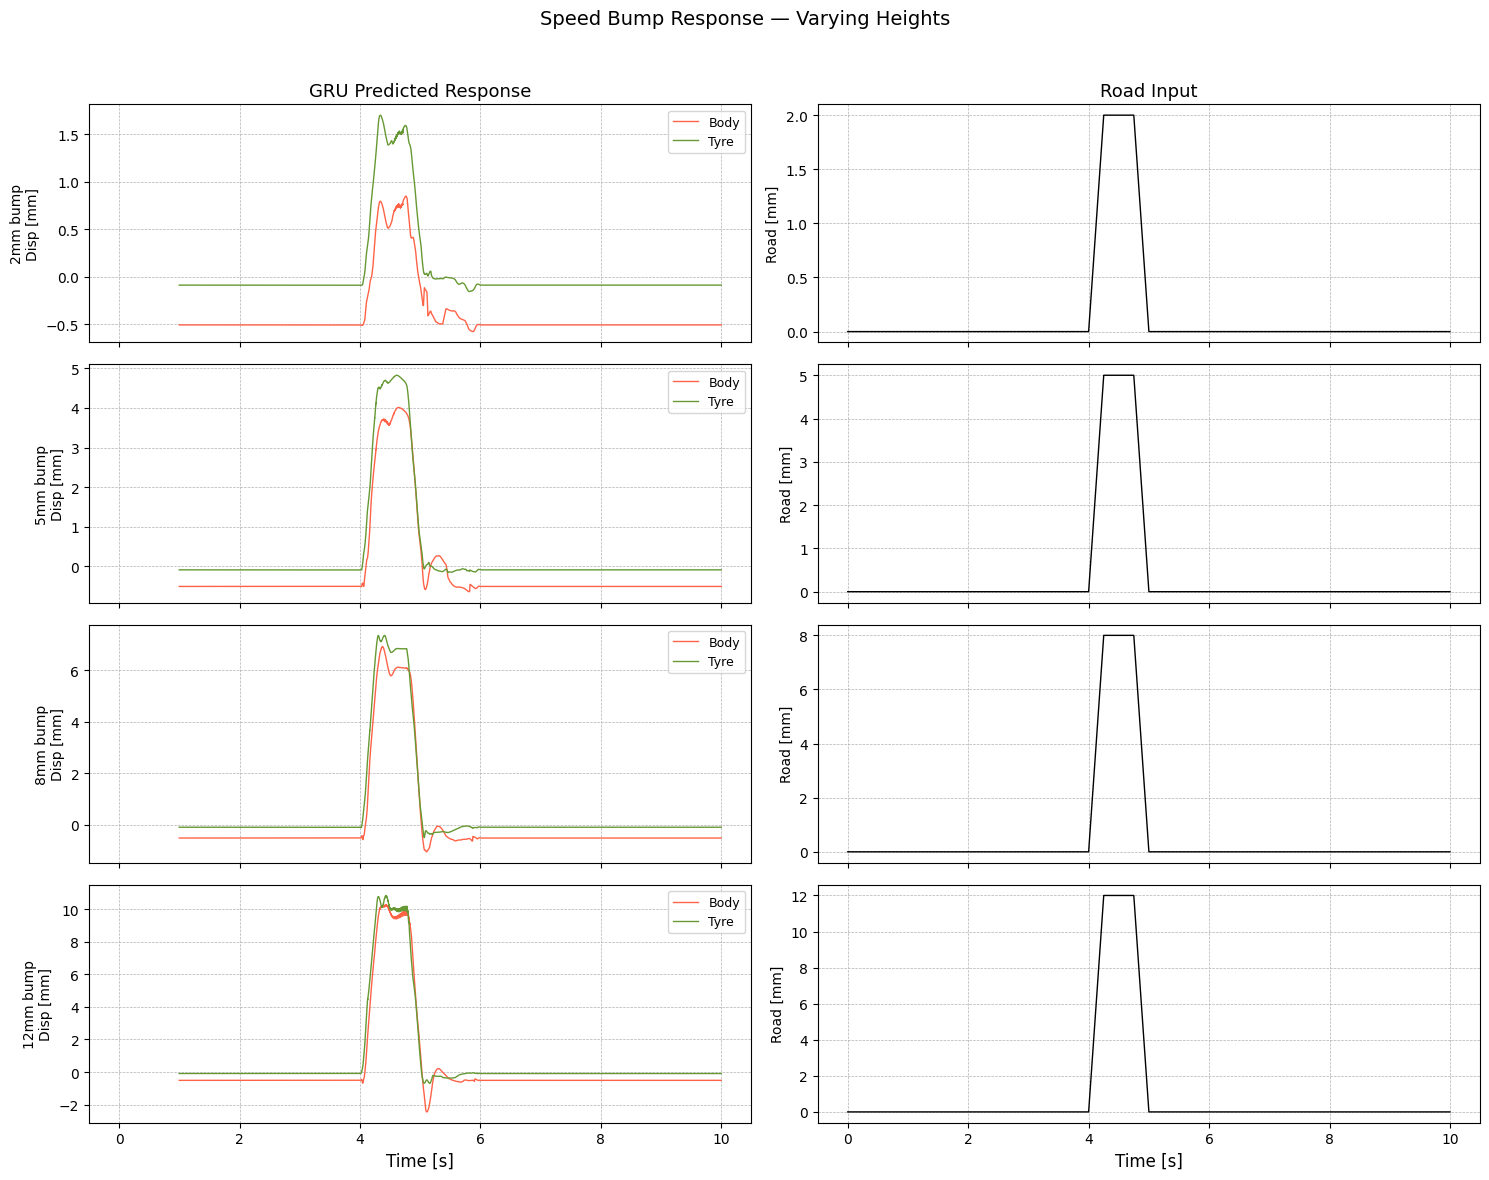

In [23]:
def speed_bump(t, start, width, height):
    """Trapezoidal bump: 25% ramp up, 50% flat, 25% ramp down."""
    road = np.zeros_like(t)
    ramp, flat = width * 0.25, width * 0.5
    t1, t2, t3, t4 = start, start + ramp, start + ramp + flat, start + width
    up, top, down = (t >= t1) & (t < t2), (t >= t2) & (t < t3), (t >= t3) & (t < t4)
    road[up]   = height * ((t[up] - t1) / ramp)
    road[top]  = height
    road[down] = height * (1 - (t[down] - t3) / ramp)
    return road


bump_heights = [0.002, 0.005, 0.008, 0.012]     # 2, 5, 8, 12 mm
t_pred = t_test[SEQ_LEN - 1:]

fig, axes = plt.subplots(len(bump_heights), 2, figsize=(15, 3 * len(bump_heights)), sharex=True)
for row, h in enumerate(bump_heights):
    road = speed_bump(t_test, start=4.0, width=1.0, height=h)
    pb, pt = predict(road)

    axes[row, 0].plot(t_pred, pb * 1000, color='tomato', lw=1.0, label='Body')
    axes[row, 0].plot(t_pred, pt * 1000, color='#669933', lw=1.0, label='Tyre')
    axes[row, 0].set_ylabel(f'{h * 1000:.0f}mm bump\nDisp [mm]', fontsize=10)
    axes[row, 0].legend(fontsize=9)
    axes[row, 0].grid(True, linestyle='--', linewidth=0.5)

    axes[row, 1].plot(t_test, road * 1000, 'k', lw=1.0)
    axes[row, 1].set_ylabel('Road [mm]', fontsize=10)
    axes[row, 1].grid(True, linestyle='--', linewidth=0.5)

axes[0, 0].set_title('GRU Predicted Response', fontsize=13)
axes[0, 1].set_title('Road Input', fontsize=13)
axes[-1, 0].set_xlabel('Time [s]', fontsize=12)
axes[-1, 1].set_xlabel('Time [s]', fontsize=12)
plt.suptitle('Speed Bump Response — Varying Heights', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

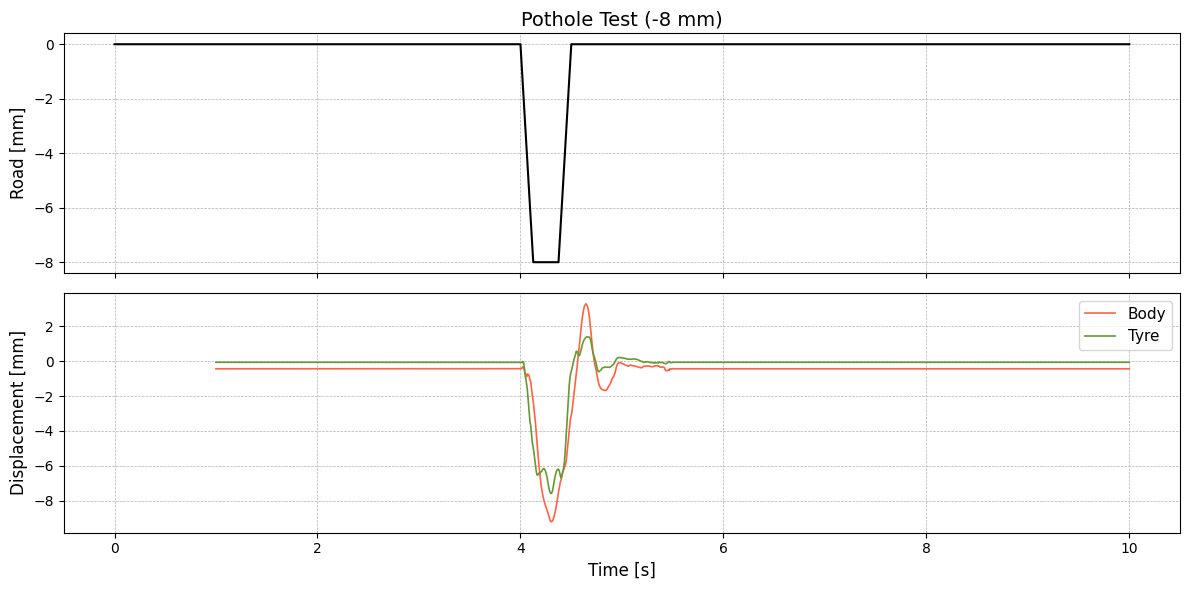

In [ ]:
road_pothole = speed_bump(t_test, start=4.0, width=0.5, height=-0.008)   # -8 mm
pb, pt = predict(road_pothole)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t_test, road_pothole * 1000, 'k', lw=1.5)
axes[0].set_ylabel('Road [mm]', fontsize=12)
axes[0].set_title('Pothole Test (-8 mm)', fontsize=14)
axes[0].grid(True, linestyle='--', linewidth=0.5)

axes[1].plot(t_pred, pb * 1000, color='tomato', lw=1.2, label='Body')
axes[1].plot(t_pred, pt * 1000, color='#669933', lw=1.2, label='Tyre')
axes[1].set_ylabel('Displacement [mm]', fontsize=12)
axes[1].set_xlabel('Time [s]', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## Summary table

In [ ]:
print('=' * 60)
print('MODEL SUMMARY')
print('=' * 60)
print('Architecture:     2-layer GRU + 3-layer MLP decoder')
print(f'Hidden dim:       {HIDDEN_DIM}')
print(f'FC width:         {FC_WIDTH}')
print(f'Parameters:       {N_PARAMS:,}')
print(f'Sequence length:  {SEQ_LEN} ({SEQ_LEN * Ts * 1000:.0f} ms)')
print('Normalisation:    Z-score (global)')
print(f'Evaluated on:     ISO 8608 classes A–E, unsuppressed, period 2 ({N:,} samples/class)')
print()
print('PER-CLASS PERFORMANCE:')
print(f'{"Class":<8} {"Body RMSE [mm]":<16} {"Tyre RMSE [mm]":<16} {"Body r":<10} {"Tyre r":<10}')
print('-' * 60)
for cls in CLASSES:
    b, t = class_results[cls]['body'], class_results[cls]['tyre']
    print(f'{cls:<8} {b["rmse"]:<16.4f} {t["rmse"]:<16.4f} {b["corr"]:<10.4f} {t["corr"]:<10.4f}')

MODEL SUMMARY
Architecture:     2-layer GRU + 3-layer MLP decoder
Hidden dim:       128
FC width:         200
Parameters:       255,978
Sequence length:  1000 (1000 ms)
Normalisation:    Z-score (global)
Evaluated on:     ISO 8608 classes A–E, unsuppressed, period 2 (100,000 samples/class)

PER-CLASS PERFORMANCE:
Class    Body RMSE [mm]   Tyre RMSE [mm]   Body r     Tyre r    
------------------------------------------------------------
A        0.0266           0.0196           0.9953     0.9977    
B        0.0306           0.0251           0.9990     0.9993    
C        0.0330           0.0353           0.9994     0.9995    
D        0.0551           0.0571           0.9996     0.9996    
E        0.0801           0.0956           0.9997     0.9997    


## Hammerstein–Wiener baseline comparison (class A, cross-road)

The MATLAB benchmark evaluates on `[hsA hsA hsA]` (a road the model never saw) and
zero-mean-centres the targets before scoring, so the GRU prediction is centred the
same way. Everything is trimmed by `SEQ_LEN-1` so the three series stay aligned.

In [ ]:
hw = sio.loadmat('HW_Benchmark_Predictions.mat')

nn_input_val_diff = np.concatenate([raw['hsA'].flatten()] * 3)          # 300,000
target_val_diff   = raw['bodysA'].flatten()[N:4 * N]                    # 300,000
target_val_diff   = target_val_diff - target_val_diff.mean()            # MATLAB centres targets

hw_body_val_diff = hw['HW_Body_ValDiff'][0, 0].flatten()

nn_body, nn_tyre = predict(nn_input_val_diff)
nn_body = nn_body - nn_body.mean()

target_val_diff  = align(target_val_diff)
hw_body_val_diff = align(hw_body_val_diff)
time_axis        = np.arange(len(nn_body)) * Ts

print(f'Aligned length: {len(nn_body):,} samples')
for label, pred in [('HW baseline', hw_body_val_diff), ('GRU', nn_body)]:
    rmse = np.sqrt(np.mean((pred - target_val_diff) ** 2))
    fit  = 100 * (1 - np.linalg.norm(target_val_diff - pred) / np.linalg.norm(target_val_diff))
    print(f'  {label:12s}  RMSE: {rmse * 1000:.4f} mm   FIT: {fit:.2f}%')

FileNotFoundError: [Errno 2] No such file or directory: 'HW_Benchmark_Predictions.mat'

In [ ]:
# ── Time domain (zoomed) ─────────────────────────────────────────────────────
zoom = 2000
plt.figure(figsize=(12, 5))
plt.plot(time_axis[:zoom], target_val_diff[:zoom], 'k-', lw=2, label='Ground Truth (Target)')
plt.plot(time_axis[:zoom], hw_body_val_diff[:zoom], 'b--', lw=1.5, label='HW Model Baseline')
plt.plot(time_axis[:zoom], nn_body[:zoom], 'r-.', lw=1.5, label='Neural Network')
plt.title('Time-Domain Response: Cross-Road Generalization (Class A)')
plt.xlabel('Time [seconds]')
plt.ylabel('Vertical Displacement [m]')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Frequency domain ─────────────────────────────────────────────────────────
Nfft = len(target_val_diff)
freq_axis = np.arange(1, Nfft + 1) * (1 / (Nfft * Ts))
psd = lambda y: (np.abs(np.fft.fft(y)) ** 2) / Nfft      # matches MATLAB's formula

plt.figure(figsize=(10, 6))
plt.loglog(freq_axis, psd(target_val_diff), 'k', alpha=0.5, label='Ground Truth')
plt.loglog(freq_axis, psd(hw_body_val_diff), 'b', lw=1.5, label='HW Model Baseline')
plt.loglog(freq_axis, psd(nn_body), 'r', lw=1.5, label='Neural Network')
plt.title('Frequency Response Magnitude (Power Spectral Density)')
plt.xlabel('Spatial Frequency [cycles/m] (approx. Hz)')
plt.ylabel('Magnitude')
plt.xlim([0.1, 1000])
plt.legend(loc='upper right')
plt.grid(True, which='both', ls='--', alpha=0.7)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined